In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
import pathlib
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline


In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig6_reward_stability')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:

rows = []
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        sess = u.single_mouse_concat_sessions(mouse, np.arange(6), trial_mat_keys=['F_dff'], timeseries_keys=['F_dff'])
        rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
        rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

        if sess.novel_arm == 1: 
            rz_nov = rz_late
            rz_fam = rz_early
        else: 
            rz_nov = rz_early
            rz_fam = rz_late

        pc_mask = sess.fam_place_cell_mask()+sess.nov_place_cell_mask()
        # print(pc_mask.shape)

        nov_mask= sess.trial_info['LR']==sess.novel_arm
        for day in range(5):

            day_mask = sess.trial_info['sess_num']==day

            tmat_nov = np.nanmean(sess.trial_matrices['F_dff'][nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
            maxpos_nov = np.nanargmax(tmat_nov, axis=0)
            rel_pos_nov = maxpos_nov-rz_nov[0]
            rz_cell_nov = (maxpos_nov>=(rz_nov[0]-5)) * (maxpos_nov<=(rz_nov[0]-1))

            tmat_fam = np.nanmean(sess.trial_matrices['F_dff'][~nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
            # print(tmat_fam.shape)
            maxpos_fam = np.nanargmax(tmat_fam, axis=0)
            rel_pos_fam = maxpos_fam - rz_fam[0]
            rz_cell_fam = (maxpos_fam>=(rz_fam[0]-5)) * (maxpos_fam<=(rz_fam[0]-1))

            r_cell_mask = rz_cell_fam * rz_cell_nov * (np.abs(rel_pos_fam-rel_pos_nov)<=2)
            # r_cell_mask = (np.abs(rel_pos_fam-rel_pos_nov)<=2)
            o_cell_mask = ~r_cell_mask
            
            for next_day in range(day+1,6):
                next_day_mask = sess.trial_info['sess_num']==next_day
                for ttype in ('nov', 'fam'):
                    if ttype == 'nov':
                        n_mask = nov_mask
                        rz = rz_nov
                        day_mat = tmat_nov
                        day_rel_pos  =rel_pos_nov
                        day_pos = maxpos_nov
                        
                    else:
                        n_mask = ~nov_mask
                        rz = rz_fam
                        day_mat = tmat_fam
                        day_rel_pos = rel_pos_nov
                        day_pos = maxpos_fam
                       
                    
                    next_day_tmat = np.nanmean(sess.trial_matrices['F_dff'][n_mask*next_day_mask,:,:][:,:,pc_mask],axis=0)
                    next_day_pos = np.nanargmax(next_day_tmat,axis=0)
                    next_day_rel_pos = next_day_pos-rz[0]
                    
                    next_day_corr = np.zeros([next_day_tmat.shape[1],])
                    for cell in range(next_day_tmat.shape[1]):
                        r, _ = sp.stats.pearsonr(day_mat[:,cell], next_day_tmat[:,cell])
                        next_day_corr[cell]=r

                    for (d_rp, nd_rp, ndc, d_p, nd_p) in zip(day_rel_pos[r_cell_mask], 
                                            next_day_rel_pos[r_cell_mask],
                                            next_day_corr[r_cell_mask], 
                                            day_pos[r_cell_mask], 
                                            next_day_pos[r_cell_mask]):
                        rows.append({'cond': cond,
                                    'mouse': mouse, 
                                    'day': day,
                                    'next_day': next_day,
                                    'ttype': ttype,
                                    'reward_cell': True,
                                    'day_rel_pos': d_rp,
                                    'next_day_rel_pos': nd_rp,
                                    'next_day_corr': ndc,
                                    'day_pos': d_p,
                                    'next_day_pos': nd_p})
                    
                        
                    for (d_rp, nd_rp, ndc, d_p, nd_p) in zip(day_rel_pos[o_cell_mask], 
                                            next_day_rel_pos[o_cell_mask],
                                            next_day_corr[o_cell_mask],
                                            day_pos[o_cell_mask], 
                                            next_day_pos[o_cell_mask]):
                        rows.append({'cond': cond,
                                    'mouse': mouse, 
                                    'day': day,
                                    'next_day': next_day,
                                    'ttype': ttype,
                                    'reward_cell': False,
                                    'day_rel_pos': d_rp,
                                    'next_day_rel_pos': nd_rp,
                                    'next_day_corr': ndc,
                                    'day_pos': d_p,
                                    'next_day_pos': nd_p})

df = pd.DataFrame(rows)
df['pos_diff']= np.abs(df['next_day_rel_pos']-df['day_rel_pos'])


4467331.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467331.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467333.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


05_12_2020 YMaze_LNovel
mCherry6
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry7
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry8
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
mCherry9
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


28_09_2020 YMaze_LNovel


...

01_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


02_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


03_10_2020 YMaze_LNovel
4467975.4
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
4467975.5
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
Cre7
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
22_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
Cre9
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


# Correlation across days

In [14]:
# correlation matrices across days

corr_mat = {}
for cond, mice  in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):

    corr_mat[cond] = {'fam': {'rr_cell': None,
                              'tr_cell': None},
                      'nov': {'rr_cell': None,
                              'tr_cell': None}
                     }
    print(cond)

    for ttype in ('fam', 'nov'):
        for reward_cell in (False, True):
            mat = np.nan*np.zeros([6,6, len(mice)])
            for day in range(5):
                for next_day in range(day+1, 6):
                
                    mask = (df['cond']==cond) * (df['day']==day) * (df['next_day']==next_day) * (df['ttype']==ttype) * (df['reward_cell']==reward_cell)

                    tmp_df = df.loc[mask].groupby(['mouse', 'reward_cell'])['next_day_corr'].mean().reset_index()
                    # print(tmp_df['mouse'].unique())
                    # print(cond, ttype, reward_cell, day, next_day)
                    for i, mouse in enumerate(mice):
                        mouse_mask = tmp_df['mouse']==mouse
                        if mouse_mask.sum()>0:
                            mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values

            if reward_cell:
                corr_mat[cond][ttype]['rr_cell'] = mat
            else:
                corr_mat[cond][ttype]['tr_cell'] = mat




ctrl


/tmp/ipykernel_316477/1697381474.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp/ipykernel_316477/1697381474.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp/ipykernel_316477/1697381474.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp

ko


/tmp/ipykernel_316477/1697381474.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp/ipykernel_316477/1697381474.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp/ipykernel_316477/1697381474.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp

/tmp/ipykernel_316477/2610321070.py:6: RuntimeWarning: Mean of empty slice
  h = ax[i,0].imshow(np.nanmean(tr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
/tmp/ipykernel_316477/2610321070.py:11: RuntimeWarning: Mean of empty slice
  h=ax[i,1].imshow(np.nanmean(rr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
/tmp/ipykernel_316477/2610321070.py:16: RuntimeWarning: Mean of empty slice
  h=ax[i,2].imshow(np.nanmean(diff_mat, axis=-1), cmap='PuOr', vmin=-.1, vmax=.1)


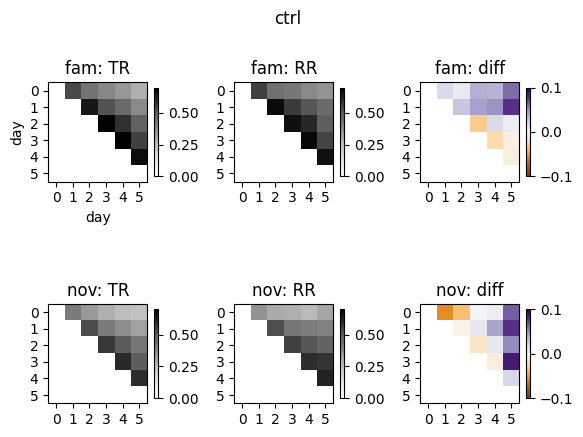

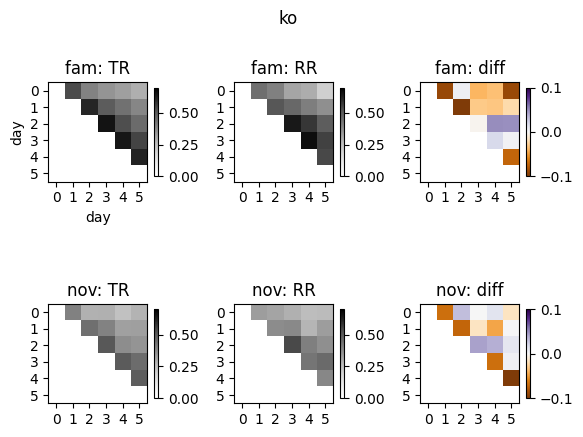

In [61]:
for cond in ('ctrl', 'ko'):
    fig, ax = plt.subplots(2,3)
    fig.subplots_adjust(wspace=.5, hspace=.5)
    for i, ttype in enumerate(('fam', 'nov')):
        tr_mat = corr_mat[cond][ttype]['tr_cell']
        h = ax[i,0].imshow(np.nanmean(tr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
        ax[i,0].set_title(f'{ttype}: TR')
        fig.colorbar(h, shrink=.6)

        rr_mat = corr_mat[cond][ttype]['rr_cell']
        h=ax[i,1].imshow(np.nanmean(rr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
        ax[i,1].set_title(f'{ttype}: RR')
        fig.colorbar(h, shrink=.6)

        diff_mat = rr_mat-tr_mat
        h=ax[i,2].imshow(np.nanmean(diff_mat, axis=-1), cmap='PuOr', vmin=-.1, vmax=.1)
        ax[i,2].set_title(f'{ttype}: diff')
        fig.colorbar(h, shrink=.6)

    fig.suptitle(cond)

    for a in ax.flatten():
        a.set_xticks(np.arange(6))
        a.set_yticks(np.arange(6))
    ax[0,0].set_xlabel('day')
    ax[0,0].set_ylabel('day')

    fig.savefig(figdir / f'{cond}_next_day_corr_heatmaps.svg')

/tmp/ipykernel_316477/1547353712.py:5: RuntimeWarning: Mean of empty slice
  h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=.7)
/tmp/ipykernel_316477/1547353712.py:10: RuntimeWarning: Mean of empty slice
  h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=.7)


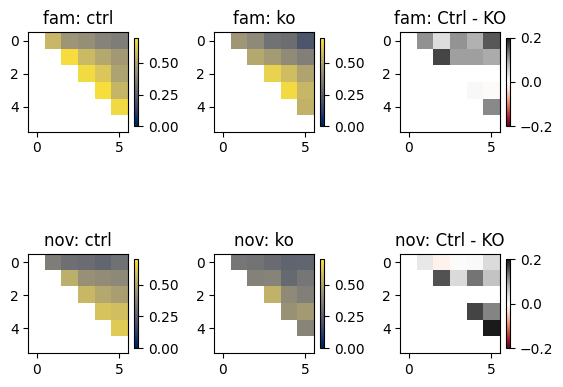

In [69]:
fig, ax = plt.subplots(2,3)
fig.subplots_adjust(wspace=.5, hspace=.5)
for r, ttype in enumerate(('fam','nov')):
    ctrl_rr_mat = corr_mat['ctrl'][ttype]['rr_cell']
    h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=.7)
    ax[r,0].set_title(f'{ttype}: ctrl')
    fig.colorbar(h, shrink=.6)

    ko_rr_mat = corr_mat['ko'][ttype]['rr_cell']
    h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=.7)
    ax[r,1].set_title(f'{ttype}: ko')
    fig.colorbar(h, shrink=.6)

    diff = ctrl_rr_mat.mean(axis=-1) - ko_rr_mat.mean(axis=-1)
    h = ax[r,2].imshow(diff, cmap='RdGy', vmin=-.2, vmax=.2)
    fig.colorbar(h, shrink=.6)
    ax[r,2].set_title(f'{ttype}: Ctrl - KO')
fig.savefig(figdir / 'next_day_corr_heatmaps.svg')

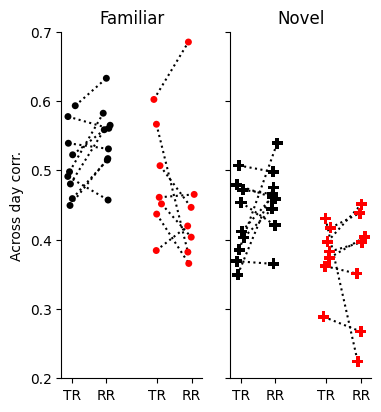

In [70]:

fig, ax = plt.subplots(1,2,figsize=[4,4.5], sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'ttype', 'reward_cell'])['next_day_corr'].mean().reset_index()
tmp_df['tmp_x'] = 1.*(tmp_df['cond']=='ko')
sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='next_day_corr', hue='reward_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[0], legend=False, dodge=True)
d=0
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='next_day_corr', hue='reward_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=0
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='next_day_corr', hue='reward_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[0], legend=False, dodge=True)
d=2
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='next_day_corr', hue='reward_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=2
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax[0].set_title('Familiar')
ax[1].set_title('Novel')
for a in ax.flatten():
    a.set_xticks([-.2, .2, .8,1.2], labels=['TR', 'RR', 'TR', 'RR'])

    a.set_ylim([.2,.7])
    
    a.set_ylabel('Across day corr.')
    a.set_xlabel('')

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig(figdir / f'next_day_corr_summary.svg')

In [17]:
rr_ctrl =  tmp_df.loc[(tmp_df['reward_cell']==True) * (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='nov')]
tr_ctrl = tmp_df.loc[(tmp_df['reward_cell']==False) * (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='nov')]
diff_ctrl = tr_ctrl['next_day_corr'].values - rr_ctrl['next_day_corr'].values

rr_ko =  tmp_df.loc[(tmp_df['reward_cell']==True) * (tmp_df['cond']=='ko') * (tmp_df['ttype']=='nov')]
tr_ko = tmp_df.loc[(tmp_df['reward_cell']==False) * (tmp_df['cond']=='ko') * (tmp_df['ttype']=='nov')]
diff_ko = tr_ko['next_day_corr'].values - rr_ko['next_day_corr'].values

In [18]:
t,p = sp.stats.wilcoxon(diff_ctrl)
print(t,p)
t,p = sp.stats.wilcoxon(diff_ko)
print(t,p)

15.0 0.42578125
12.0 0.8125


In [19]:
t, p = sp.stats.mannwhitneyu(rr_ctrl['next_day_corr'].values, rr_ko['next_day_corr'].values)
print(t, p)

56.0 0.007867132867132868


In [20]:
t, p = sp.stats.mannwhitneyu(tr_ctrl['next_day_corr'].values, tr_ko['next_day_corr'].values)
print(t, p)

45.0 0.1737762237762238


In [21]:
import statsmodels.formula.api as smf
df_tmp =df.copy()
df_tmp['cond'] = df_tmp['cond'].astype('category')
df_tmp['mouse'] = df_tmp['mouse'].astype('category')
df_tmp['day'] = df_tmp['day'].astype('category')
df_tmp['next_day'] = df_tmp['next_day'].astype('category')
df_tmp['ttype'] = df_tmp['ttype'].astype('category')
df_tmp['reward_cell'] = df_tmp['reward_cell'].astype('category')
df_tmp['next_day_corr_z'] = np.arctanh(df_tmp['next_day_corr'])
df_tmp['next_day_corr_rank'] = df_tmp['next_day_corr'].rank()


In [22]:
mdl = smf.mixedlm('next_day_corr_rank ~ day  + ttype + reward_cell*cond', df_tmp, groups=df_tmp['mouse'])
res = mdl.fit()
res.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Mixed Linear Model Regression Results
========================================================================================
Model:                    MixedLM         Dependent Variable:         next_day_corr_rank
No. Observations:         161190          Method:                     REML              
No. Groups:               16              Scale:                      1985332705.4354   
Min. group size:          2100            Log-Likelihood:             -1954151.4024     
Max. group size:          16800           Converged:                  Yes               
Mean group size:          10074.4                                                       
----------------------------------------------------------------------------------------
                                  Coef.     Std.Err.    z    P>|z|   [0.025     0.975]  
----------------------------------------------------------------------------------------
Intercept                         77132.907 1877.469  41.083 0.000  73453.136  80812.678
day[T.1]                          10933.872  288.448  37.906 0.000  10368.524  11499.221
day[T.2]                          18961.391  313.958  60.395 0.000  18346.045  19576.738
day[T.3]                          25092.577  359.714  69.757 0.000  24387.550  25797.604
day[T.4]                          28854.483  470.989  61.264 0.000  27931.361  29777.605
ttype[T.nov]                     -11479.228  221.961 -51.717 0.000 -11914.265 -11044.192
reward_cell[T.True]                1655.686  531.620   3.114 0.002    613.731   2697.641
cond[T.ko]                        -6127.802 2828.252  -2.167 0.030 -11671.074   -584.529
reward_cell[T.True]:cond[T.ko]    -4030.396 1039.199  -3.878 0.000  -6067.188  -1993.604
Group Var                      31204463.561  265.006                                    
========================================================================================

"""

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 161190.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk: W=0.975, p=2.65e-86
D'Agostino: χ²=42320.153, p=0


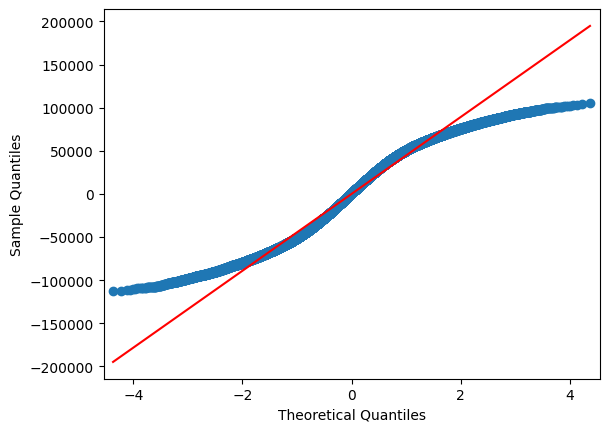

In [23]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

# Place field shift

In [24]:
df.head()

,cond,mouse,day,next_day,ttype,reward_cell,day_rel_pos,next_day_rel_pos,next_day_corr,day_pos,next_day_pos,pos_diff
0,ctrl,4467331.1,0,1,nov,True,-2,-5,0.625234,18,15,3
1,ctrl,4467331.1,0,1,nov,True,-1,-1,0.359037,19,19,0
2,ctrl,4467331.1,0,1,nov,True,-4,8,-0.361242,16,28,12
3,ctrl,4467331.1,0,1,nov,True,-1,-3,0.732933,19,17,2
4,ctrl,4467331.1,0,1,nov,True,-1,-20,-0.089530,19,0,19


In [25]:
df['abs_rel_pos_shift'] = np.abs(df['day_rel_pos']-df['next_day_rel_pos'])
df['abs_pos_shift'] = np.abs(df['day_pos']-df['next_day_pos'])
df['pos_shift'] = df['next_day_pos']-df['day_pos']

In [26]:
shift_mat = {}
for cond, mice  in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):

    shift_mat[cond] = {'fam': {'rr_cell': None,
                              'tr_cell': None},
                      'nov': {'rr_cell': None,
                              'tr_cell': None}
                     }

    for ttype in ('fam', 'nov'):
        for reward_cell in (False, True):
            mat = np.nan*np.zeros([6,6, len(mice)])
            for day in range(5):
                for next_day in range(day+1, 6):
                
                    mask = (df['cond']==cond) * (df['day']==day) * (df['next_day']==next_day) * (df['ttype']==ttype) * (df['reward_cell']==reward_cell)

                    tmp_df = df.loc[mask].groupby(['mouse', 'reward_cell'])['abs_pos_shift'].mean().reset_index()
                    for i, mouse in enumerate(mice):
                        mouse_mask = tmp_df['mouse']==mouse
                        if mouse_mask.sum()>0:
                            mat[day, next_day,i] = tmp_df.loc[mouse_mask,'abs_pos_shift'].values[0]
                    

            if reward_cell:
                shift_mat[cond][ttype]['rr_cell'] = mat
            else:
                shift_mat[cond][ttype]['tr_cell'] = mat


/tmp/ipykernel_316477/2228106287.py:6: RuntimeWarning: Mean of empty slice
  h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
/tmp/ipykernel_316477/2228106287.py:11: RuntimeWarning: Mean of empty slice
  h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)


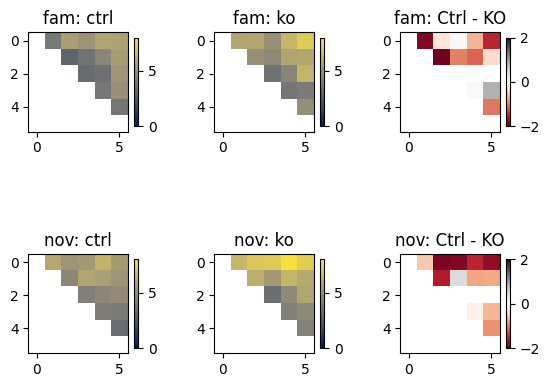

In [74]:
fig, ax = plt.subplots(2,3)
fig.subplots_adjust(wspace=.5, hspace=.5)

for r, ttype in enumerate(('fam','nov')):
    ctrl_rr_mat = shift_mat['ctrl'][ttype]['rr_cell']
    h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
    ax[r,0].set_title(f'{ttype}: ctrl')
    fig.colorbar(h, shrink=.6)

    ko_rr_mat = shift_mat['ko'][ttype]['rr_cell']
    h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
    ax[r,1].set_title(f'{ttype}: ko')
    fig.colorbar(h, shrink=.6)

    diff = ctrl_rr_mat.mean(axis=-1) - ko_rr_mat.mean(axis=-1)
    h = ax[r,2].imshow(diff, cmap='RdGy', vmin=-2, vmax=2)
    fig.colorbar(h, shrink=.6)
    ax[r,2].set_title(f'{ttype}: Ctrl - KO')
fig.savefig(figdir / 'rr_shift_heatmaps.svg')

/tmp/ipykernel_316477/2857885965.py:6: RuntimeWarning: Mean of empty slice
  h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
/tmp/ipykernel_316477/2857885965.py:11: RuntimeWarning: Mean of empty slice
  h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)


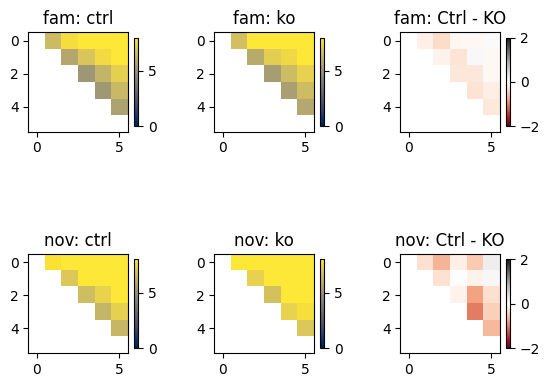

In [75]:
fig, ax = plt.subplots(2,3)
fig.subplots_adjust(wspace=.5, hspace=.5)

for r, ttype in enumerate(('fam','nov')):
    ctrl_rr_mat = shift_mat['ctrl'][ttype]['tr_cell']
    h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
    ax[r,0].set_title(f'{ttype}: ctrl')
    fig.colorbar(h, shrink=.6)

    ko_rr_mat = shift_mat['ko'][ttype]['tr_cell']
    h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
    ax[r,1].set_title(f'{ttype}: ko')
    fig.colorbar(h, shrink=.6)

    diff = ctrl_rr_mat.mean(axis=-1) - ko_rr_mat.mean(axis=-1)
    h = ax[r,2].imshow(diff, cmap='RdGy', vmin=-2, vmax=2)
    fig.colorbar(h, shrink=.6)
    ax[r,2].set_title(f'{ttype}: Ctrl - KO')
fig.savefig(figdir / 'tr_shift_heatmaps.svg')

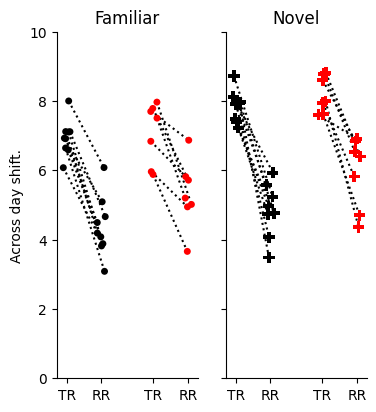

In [76]:
fig, ax = plt.subplots(1,2,figsize=[4,4.5], sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'ttype', 'reward_cell'])['abs_pos_shift'].mean().reset_index()
tmp_df['tmp_x'] = 1.*(tmp_df['cond']=='ko')
sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='abs_pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[0], legend=False, dodge=True)
d=0
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='abs_pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=0
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='abs_pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[0], legend=False, dodge=True)
d=2
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='abs_pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=2
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax[0].set_title('Familiar')
ax[1].set_title('Novel')
for a in ax.flatten():
    a.set_xticks([-.2, .2, .8,1.2], labels=['TR', 'RR', 'TR', 'RR'])

    a.set_ylim([0,10])
    
    a.set_ylabel('Across day shift.')
    a.set_xlabel('')

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
fig.savefig(figdir / 'shift_summary.svg')

In [29]:
aov = pg.mixed_anova(df, dv='abs_pos_shift',
                     subject='mouse', within='reward_cell', between='cond')
aov



,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,3.160930,1,14,3.160930,6.547455,2.272610e-02,0.318650,NaN
1,reward_cell,48.151177,1,14,48.151177,346.049747,2.864216e-11,0.961116,1.0
2,Interaction,1.191976,1,14,1.191976,8.566415,1.104031e-02,0.379609,NaN


In [30]:
res = pg.pairwise_tests(df, dv = 'abs_pos_shift',
                        subject='mouse', within='reward_cell', between='cond', parametric=False, within_first=True, padjust='holm')
res

,Contrast,reward_cell,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,reward_cell,-,False,True,True,False,NaN,0.0,two-sided,0.000031,NaN,NaN,3.624621
1,cond,-,ctrl,ko,False,False,10.0,NaN,two-sided,0.022902,NaN,NaN,-1.219177
2,reward_cell * cond,False,ctrl,ko,False,False,22.0,NaN,two-sided,0.351049,0.351049,holm,-0.429691
3,reward_cell * cond,True,ctrl,ko,False,False,7.0,NaN,two-sided,0.007867,0.015734,holm,-1.676686


In [31]:
df_tmp =df.copy()
df_tmp['cond'] = df_tmp['cond'].astype('category')
df_tmp['mouse'] = df_tmp['mouse'].astype('category')
df_tmp['day'] = df_tmp['day'].astype('category')
df_tmp['next_day'] = df_tmp['next_day'].astype('category')
df_tmp['ttype'] = df_tmp['ttype'].astype('category')
df_tmp['reward_cell'] = df_tmp['reward_cell'].astype('category')

df_tmp['abs_pos_shift_rank'] = df_tmp['abs_pos_shift'].rank()


In [32]:
mdl = smf.mixedlm('abs_pos_shift_rank ~ day + next_day + ttype + reward_cell*cond', df_tmp, groups=df_tmp['mouse'])
res = mdl.fit()
res.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Mixed Linear Model Regression Results
========================================================================================
Model:                    MixedLM         Dependent Variable:         abs_pos_shift_rank
No. Observations:         161190          Method:                     REML              
No. Groups:               16              Scale:                      2040350215.4085   
Min. group size:          2100            Log-Likelihood:             -1956319.1439     
Max. group size:          16800           Converged:                  Yes               
Mean group size:          10074.4                                                       
----------------------------------------------------------------------------------------
                                  Coef.     Std.Err.    z    P>|z|   [0.025     0.975]  
----------------------------------------------------------------------------------------
Intercept                         75928.955 1306.690  58.108 0.000  73367.890  78490.020
day[T.1]                          -8328.816  308.224 -27.022 0.000  -8932.923  -7724.709
day[T.2]                         -15364.415  344.538 -44.594 0.000 -16039.696 -14689.134
day[T.3]                         -20715.759  401.165 -51.639 0.000 -21502.028 -19929.490
day[T.4]                         -25568.095  528.834 -48.348 0.000 -26604.590 -24531.599
next_day[T.2]                      4019.574  555.464   7.236 0.000   2930.885   5108.262
next_day[T.3]                      7699.772  536.137  14.362 0.000   6648.963   8750.582
next_day[T.4]                     11181.183  528.708  21.148 0.000  10144.935  12217.431
next_day[T.5]                     15579.228  528.708  29.467 0.000  14542.980  16615.476
ttype[T.nov]                       7400.251  225.016  32.888 0.000   6959.228   7841.275
reward_cell[T.True]              -13879.677  538.934 -25.754 0.000 -14935.968 -12823.387
cond[T.ko]                         2300.123 1869.733   1.230 0.219  -1364.487   5964.733
reward_cell[T.True]:cond[T.ko]     3747.894 1053.468   3.558 0.000   1683.134   5812.654
Group Var                      13466006.069  115.337                                    
========================================================================================

"""

In [33]:
# test difference is bigger 

In [34]:


avg_shifts = {}
rel_bins = np.arange(-28,10)
pos_bins = np.arange(30)
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    avg_shifts[cond]={}
    for ttype in ('fam', 'nov'):
        avg_shifts[cond][ttype] = {}
        for reward_cell in (False, True):
            avg_shifts[cond][ttype][reward_cell]={'rel_pos': [], 'pos': []}
            for mouse in mice:
                mask = (df['cond']==cond) * (df['mouse']==mouse) * (df['ttype']==ttype) * (df['reward_cell']==reward_cell)
                # mask = (df['cond']==cond) * (df['ttype']==ttype) * (df['reward_cell']==reward_cell)
                
                tmp_df = df.loc[mask]

                
                rel_shift_bins = np.digitize(tmp_df['day_rel_pos'], bins=rel_bins)
                rel_shift_dig = np.zeros_like(rel_bins)*np.nan
                for i, b in enumerate(rel_bins):
                    mask = rel_shift_bins==i
                    if mask.sum()>0:
                        rel_shift_dig[i]=np.mean(tmp_df.loc[mask,'abs_pos_shift'].values)
                avg_shifts[cond][ttype][reward_cell]['rel_pos'].append(rel_shift_dig)

                shift_bins = np.digitize(tmp_df['day_pos'], bins=pos_bins)
                shift_dig = np.zeros_like(pos_bins)*np.nan
                for i, b in enumerate(pos_bins):
                    mask = shift_bins==i
                    if mask.sum()>0:
                        shift_dig[i]=np.mean(tmp_df.loc[mask,'abs_pos_shift'].values)
                avg_shifts[cond][ttype][reward_cell]['pos'].append(shift_dig)
        
        
            avg_shifts[cond][ttype][reward_cell]['pos'] = np.squeeze(np.array(avg_shifts[cond][ttype][reward_cell]['pos']))
            avg_shifts[cond][ttype][reward_cell]['rel_pos'] = np.squeeze(np.array(avg_shifts[cond][ttype][reward_cell]['rel_pos']))


In [35]:
avg_shifts['ctrl']['nov'][True]['rel_pos']

array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan, 8.05555556,
        5.01408451, 5.3258427 , 4.        , 4.59550562,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan, 4.30434783,
        5.35714286, 5.12328767, 5.23853211, 5.61428571,        nan,
               nan,        nan,        nan,        nan,        nan,
   

/tmp/ipykernel_316477/2731253220.py:2: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(avg_shifts['ctrl']['nov'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ctrl']['nov'][True]['rel_pos'], axis=0)
/tmp/ipykernel_316477/2731253220.py:6: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(avg_shifts['ko']['nov'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ko']['nov'][True]['rel_pos'], axis=0)
/tmp/ipykernel_316477/2731253220.py:10: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(avg_shifts['ctrl']['fam'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ctrl']['fam'][True]['rel_pos'], axis=0)
/tmp/ipykernel_316477/2731253220.py:14: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(avg_shifts['ko']['fam'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ko']['fam'][True]['rel_pos'], axis=0)
/tmp/ipykernel_316477/2731253220.py:20: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(avg_shifts['ctrl']['nov'][False]['rel_pos']

(-4.0, 2.0)

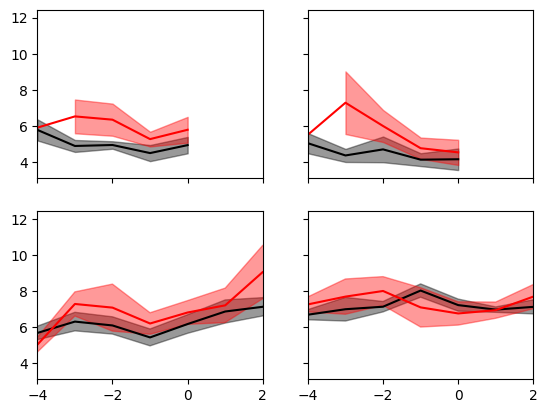

In [36]:
fig, ax = plt.subplots(2,2, sharey=True, sharex=True)
mu, sem = np.nanmean(avg_shifts['ctrl']['nov'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ctrl']['nov'][True]['rel_pos'], axis=0)
ax[0, 0].plot(rel_bins, mu, color='black')
ax[0, 0].fill_between(rel_bins, mu-sem, mu+sem, color='black', alpha=.4)

mu, sem = np.nanmean(avg_shifts['ko']['nov'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ko']['nov'][True]['rel_pos'], axis=0)
ax[0, 0].plot(rel_bins, mu, color='red')
ax[0, 0].fill_between(rel_bins, mu-sem, mu+sem, color='red', alpha=.4)

mu, sem = np.nanmean(avg_shifts['ctrl']['fam'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ctrl']['fam'][True]['rel_pos'], axis=0)
ax[0, 1].plot(rel_bins, mu, color='black')
ax[0, 1].fill_between(rel_bins, mu-sem, mu+sem, color='black', alpha=.4)

mu, sem = np.nanmean(avg_shifts['ko']['fam'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ko']['fam'][True]['rel_pos'], axis=0)
ax[0, 1].plot(rel_bins, mu, color='red')
ax[0, 1].fill_between(rel_bins, mu-sem, mu+sem, color='red', alpha=.4)


# 
mu, sem = np.nanmean(avg_shifts['ctrl']['nov'][False]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ctrl']['nov'][False]['rel_pos'], axis=0)
ax[1, 0].plot(rel_bins, mu, color='black')
ax[1, 0].fill_between(rel_bins, mu-sem, mu+sem, color='black', alpha=.4)

mu, sem = np.nanmean(avg_shifts['ko']['nov'][False]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ko']['nov'][False]['rel_pos'], axis=0)
ax[1, 0].plot(rel_bins, mu, color='red')
ax[1, 0].fill_between(rel_bins, mu-sem, mu+sem, color='red', alpha=.4)

mu, sem = np.nanmean(avg_shifts['ctrl']['fam'][False]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ctrl']['fam'][False]['rel_pos'], axis=0)
ax[1, 1].plot(rel_bins, mu, color='black')
ax[1, 1].fill_between(rel_bins, mu-sem, mu+sem, color='black', alpha=.4)

mu, sem = np.nanmean(avg_shifts['ko']['fam'][False]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ko']['fam'][False]['rel_pos'], axis=0)
ax[1, 1].plot(rel_bins, mu, color='red')
ax[1, 1].fill_between(rel_bins, mu-sem, mu+sem, color='red', alpha=.4)

ax[0,0].set_xlim([-4,2])


In [77]:
from matplotlib import gridspec

def get_rcell_mask(sess, day):
    rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
    rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

    if sess.novel_arm == 1: 
        rz_nov = rz_late
        rz_fam = rz_early
    else: 
        rz_nov = rz_early
        rz_fam = rz_late


    nov_mask= sess.trial_info['LR']==sess.novel_arm

    # pc_mask = sess.place_cell_info[-1]['masks'][day] + sess.place_cell_info[1]['masks'][day]
    day_mask = sess.trial_info['sess_num']==day

    pc_mask = sess.nov_place_cell_mask() + sess.fam_place_cell_mask()
    # place cell peak

    tmat_nov = np.nanmean(sess.trial_matrices['F_dff'][nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
    # print(tmat_nov.shape)
    maxpos_nov = np.nanargmax(tmat_nov, axis=0)
    rel_pos_nov = maxpos_nov-rz_nov[0]
    rz_cell_nov = (maxpos_nov>=(rz_nov[0]-5)) * (maxpos_nov<=(rz_nov[0]-1))

    tmat_fam = np.nanmean(sess.trial_matrices['F_dff'][~nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
    # print(tmat_fam.shape)
    maxpos_fam = np.nanargmax(tmat_fam, axis=0)
    rel_pos_fam = maxpos_fam - rz_fam[0]
    rz_cell_fam = (maxpos_fam>=(rz_fam[0]-5)) * (maxpos_fam<=(rz_fam[0]-1))

    r_cell_mask = (rz_cell_fam * rz_cell_nov) * (np.abs(rel_pos_fam-rel_pos_nov)<=2)
    # r_cell_mask = np.abs(rel_pos_fam-rel_pos_nov)<=2
    return r_cell_mask

def plot_cell_across_days(sess, cell):
    rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
    rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )
    if sess.novel_arm == -1:
        rz_nov= rz_early
        nov_color= 'blue'
        rz_fam = rz_late
        fam_color='green'
    else:
        rz_nov = rz_late
        nov_color='green'
        rz_fam = rz_early
        fam_color='blue'


    fig = plt.figure(figsize = [25, 5])
    gs = gridspec.GridSpec(6, 7, figure=fig)
    mean = np.nanmean(sess.trial_matrices['F_dff'][:,:,cell].ravel())
    for day in range(6):
        fam_mask = (sess.trial_info['sess_num']==day) & (sess.trial_info['LR']==-1*sess.novel_arm)
        nov_mask = (sess.trial_info['sess_num']==day) & (sess.trial_info['LR']==sess.novel_arm)
        fam_trialmat = sess.trial_matrices['F_dff'][fam_mask,:,:][:,:,cell]
        nov_trialmat = sess.trial_matrices['F_dff'][nov_mask,:,:][:,:,cell]
        
    
        fam_trialmat[np.isnan(fam_trialmat)]=1E-3
        nov_trialmat[np.isnan(nov_trialmat)]=1E-3
        
        

        fam_ax = fig.add_subplot(gs[day,0])
        h = fam_ax.imshow(fam_trialmat/mean, cmap = 'magma', aspect='auto', vmin = 0, vmax=10)
        fam_ax.fill_betweenx([-.5, fam_trialmat.shape[0]-.5], rz_fam[0], rz_fam[1], color=fam_color, alpha=.8)
        

        
        nov_ax = fig.add_subplot(gs[day,1])
        nov_ax.imshow(nov_trialmat/mean, cmap = 'magma', aspect='auto', vmin = 0, vmax=10)
        nov_ax.fill_betweenx([-.5, nov_trialmat.shape[0]-.5], rz_nov[0], rz_nov[1], color=nov_color, alpha=.8)
        
        
        if day<5:
            fam_ax.set_xticks([])
            nov_ax.set_xticks([])
        else:
            fam_ax.set_xticks((-.5, 9.5, 19.5, 29.5))
            fam_ax.set_xticklabels((0,100,200,300))
            
            nov_ax.set_xticks((-.5, 9.5, 19.5, 29.5))
            nov_ax.set_xticklabels((0,100,200,300))

    fig.suptitle(cell)
    return fig
    

In [ ]:
mouse = ctrl_mice[3]
sess = u.single_mouse_concat_sessions(mouse, np.arange(6), trial_mat_keys=['F_dff',], timeseries_keys=['F_dff',])

day = 1
r_cell_mask = get_rcell_mask(sess, day)
r_inds = np.argwhere(r_cell_mask).ravel()

r_inds



29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel


array([ 19,  35,  46,  48,  51,  54,  63,  73,  84,  95, 131, 151, 171,
       173, 174, 195, 199, 208, 212, 215, 235, 252, 279, 283, 284, 309,
       313, 317, 323, 326, 329, 344, 358, 380, 409, 418, 425, 426, 430,
       448, 455, 462, 474, 479, 498, 509, 512, 522, 523, 537])

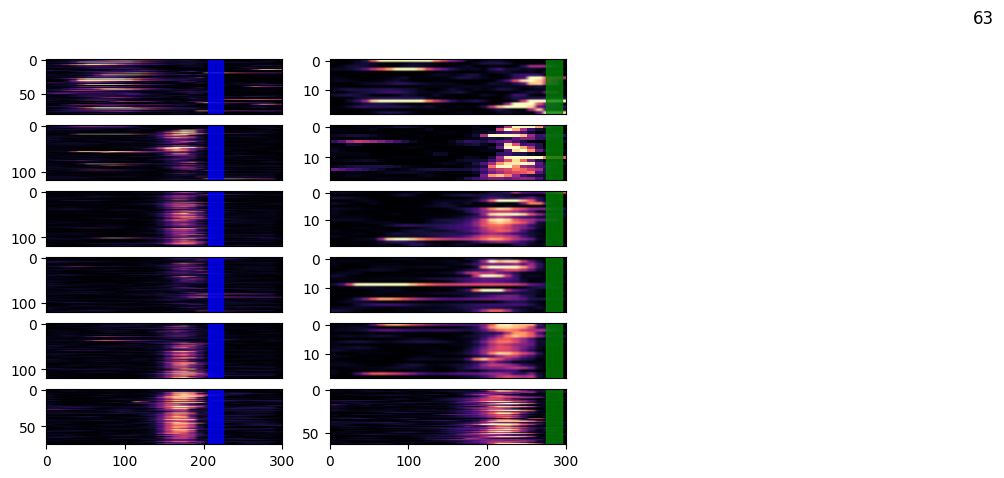

In [79]:
fig = plot_cell_across_days(sess,63)
fig.savefig(figdir / f'{mouse}_cell63.svg')

In [80]:
mouse = ko_mice[2]
sess = u.single_mouse_concat_sessions(mouse, np.arange(6), trial_mat_keys=['F_dff',], timeseries_keys=['F_dff',])

day = 1
r_cell_mask = get_rcell_mask(sess, day)
r_inds = np.argwhere(r_cell_mask).ravel()

r_inds


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


28_09_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


29_09_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


...

/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


02_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


03_10_2020 YMaze_LNovel


array([  0,   5,   7,  51,  52,  67,  68,  71,  74,  95, 150, 168, 174,
       179, 190, 191, 212, 253, 272])

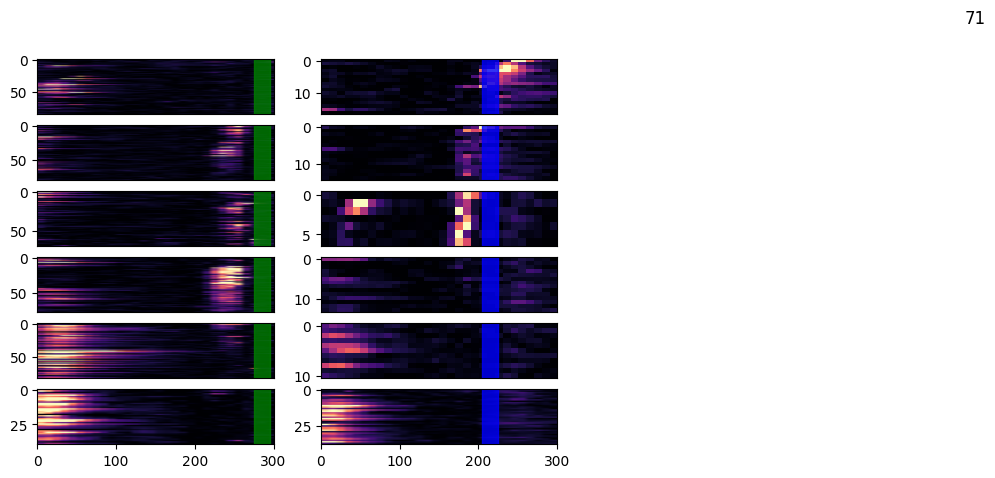

In [81]:
fig = plot_cell_across_days(sess,71)
fig.savefig( figdir / f'{mouse}_cell71.svg')

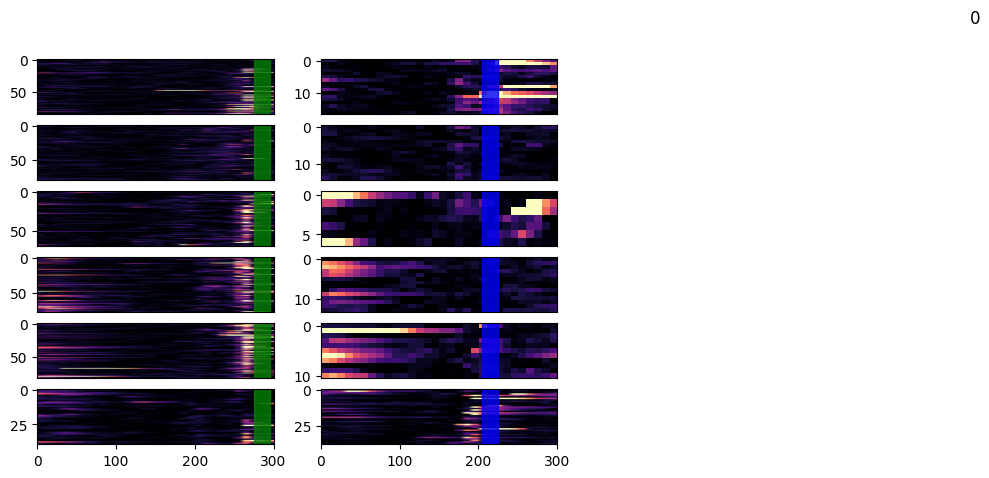

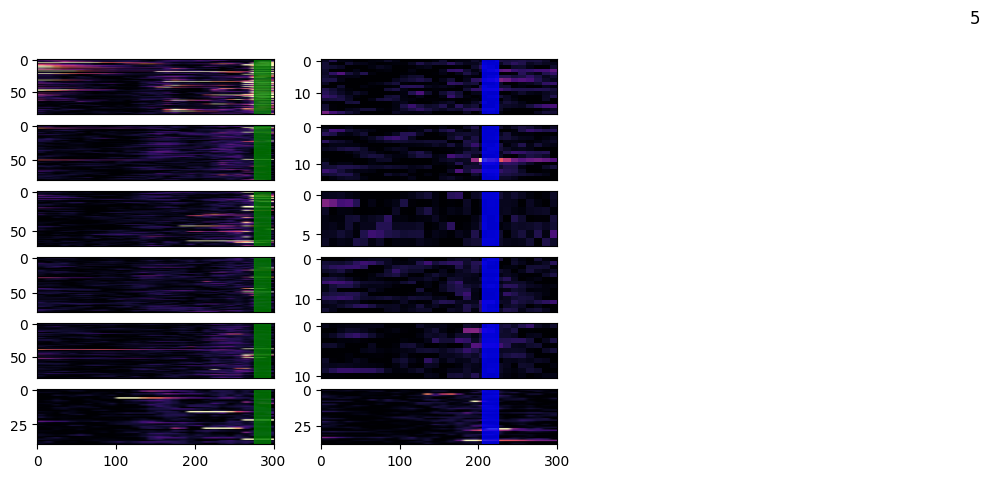

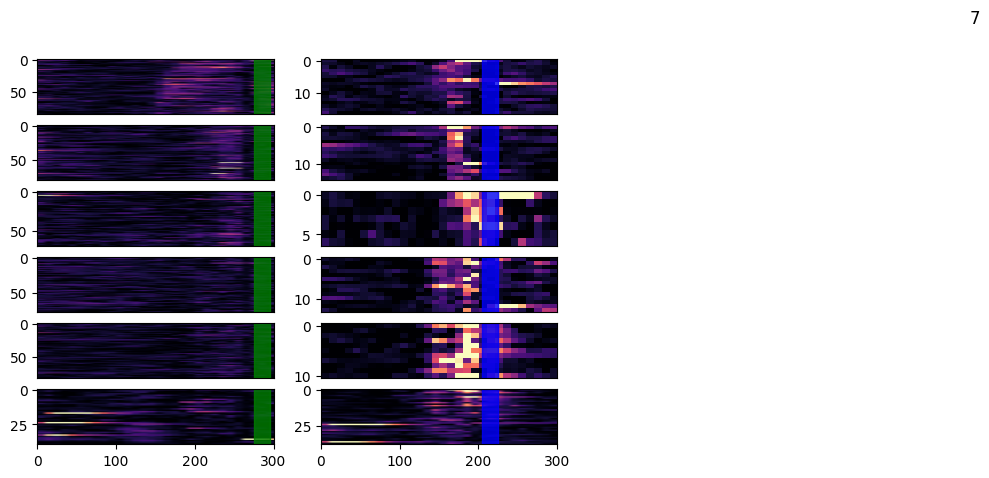

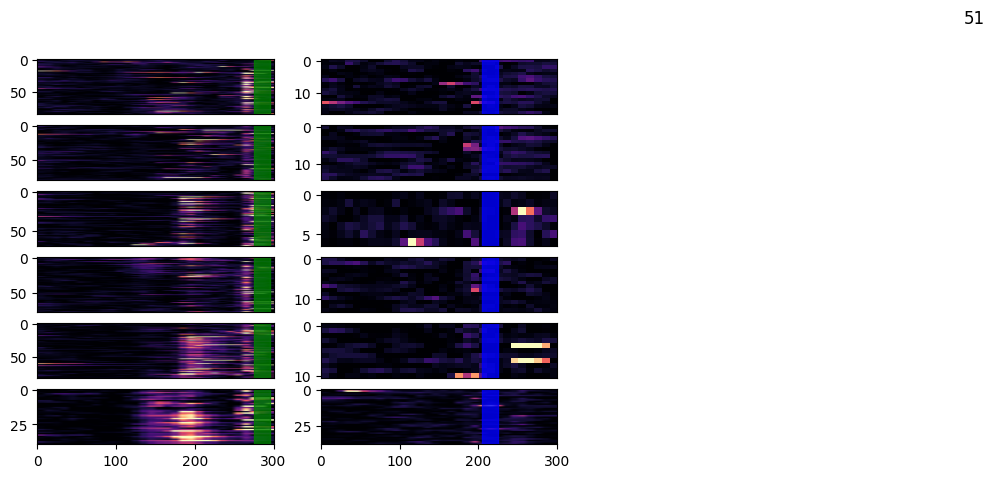

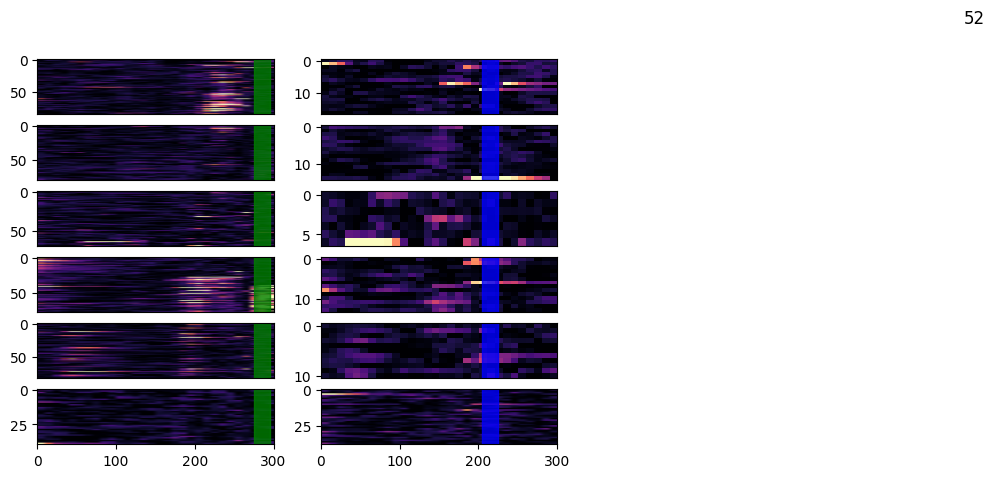

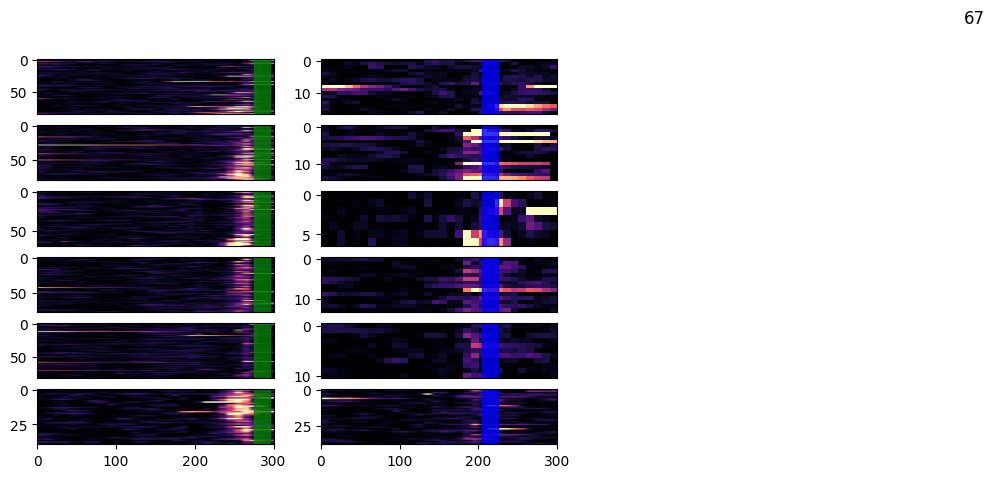

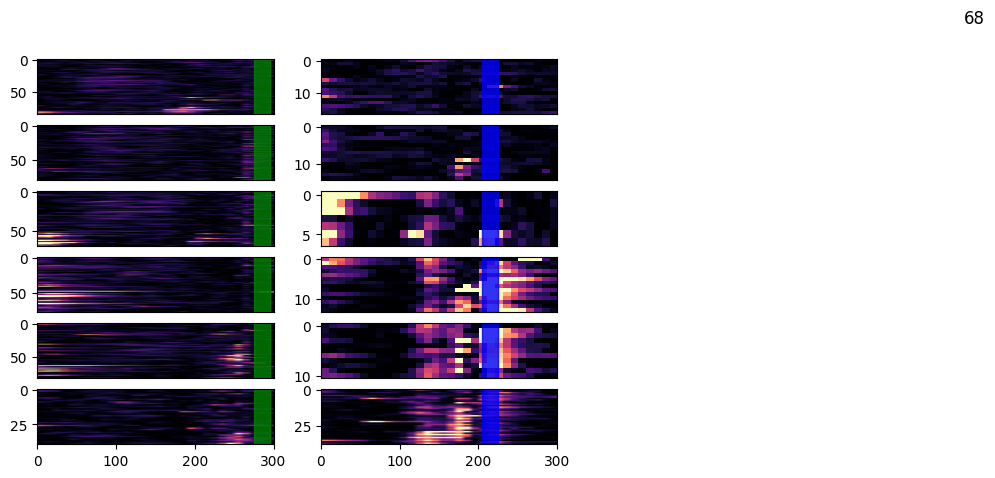

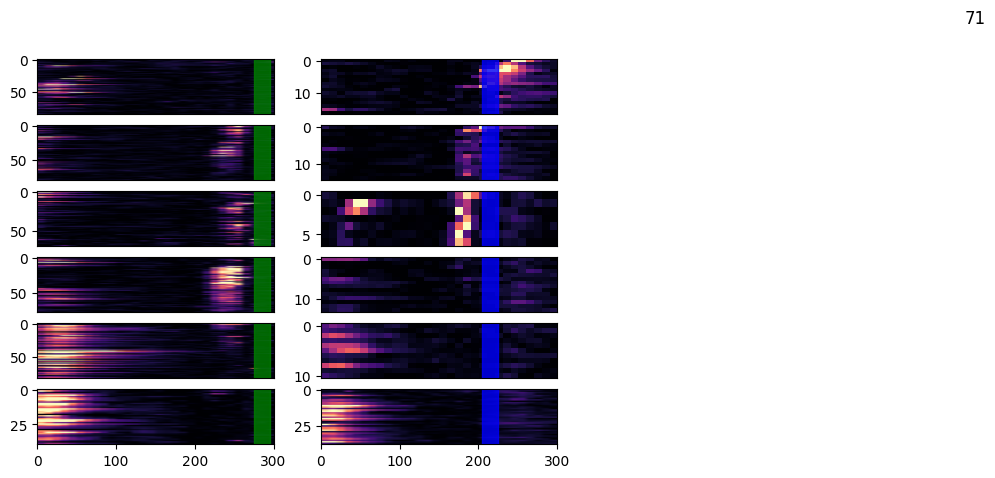

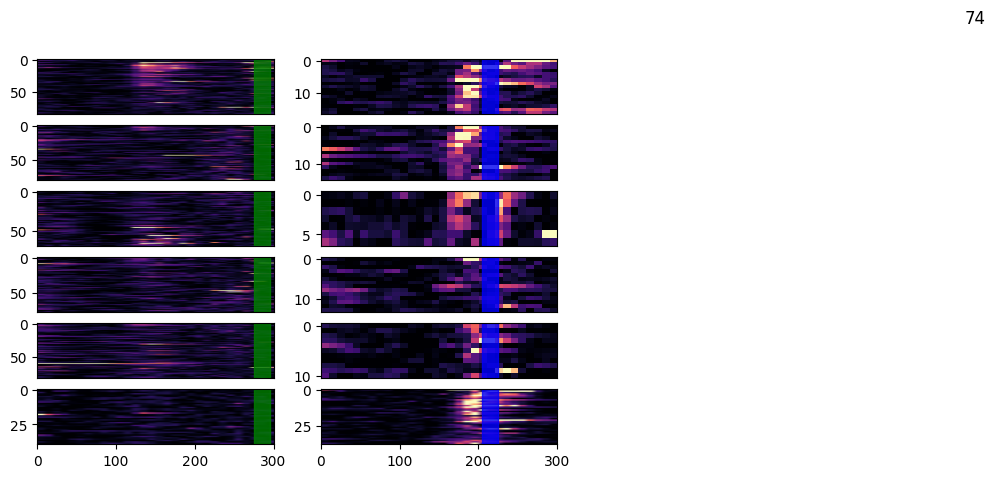

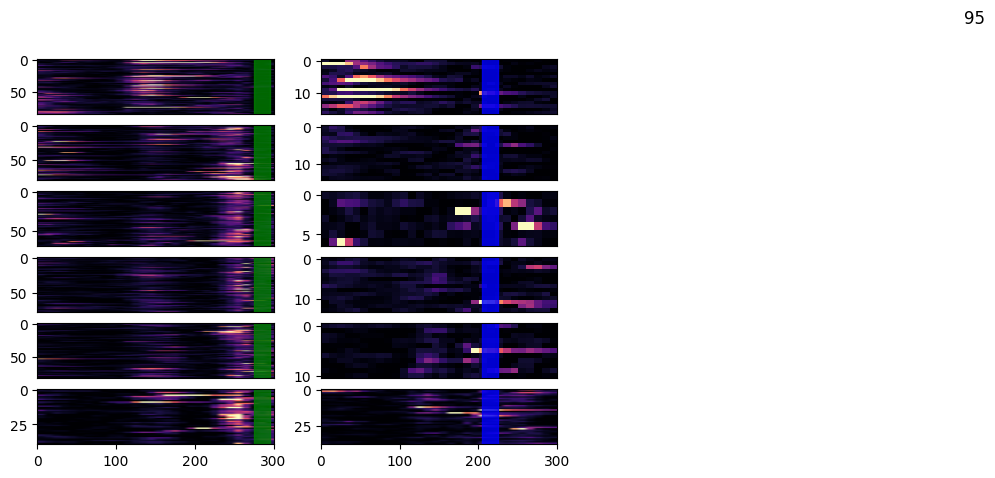

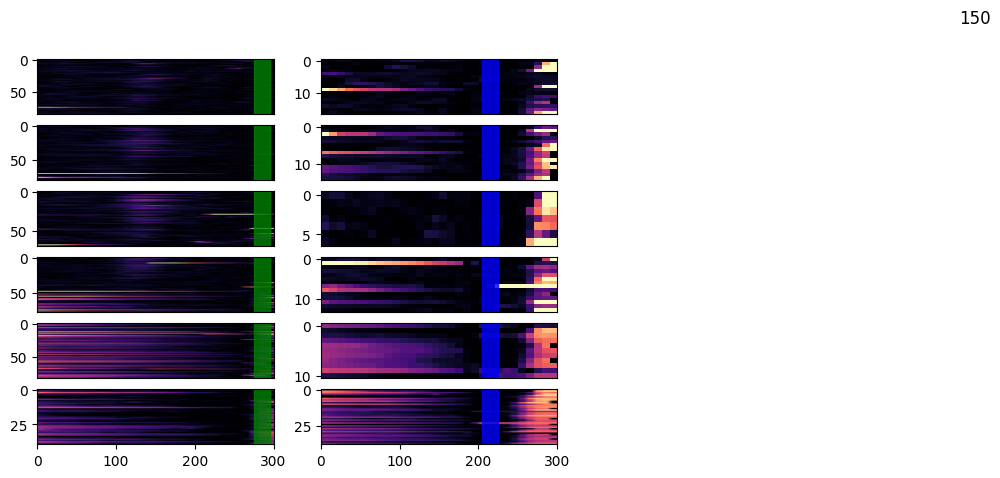

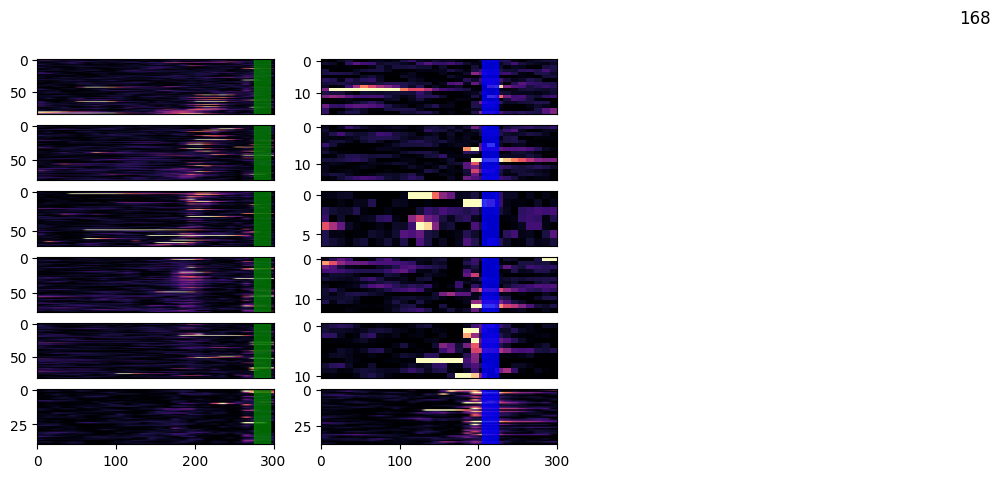

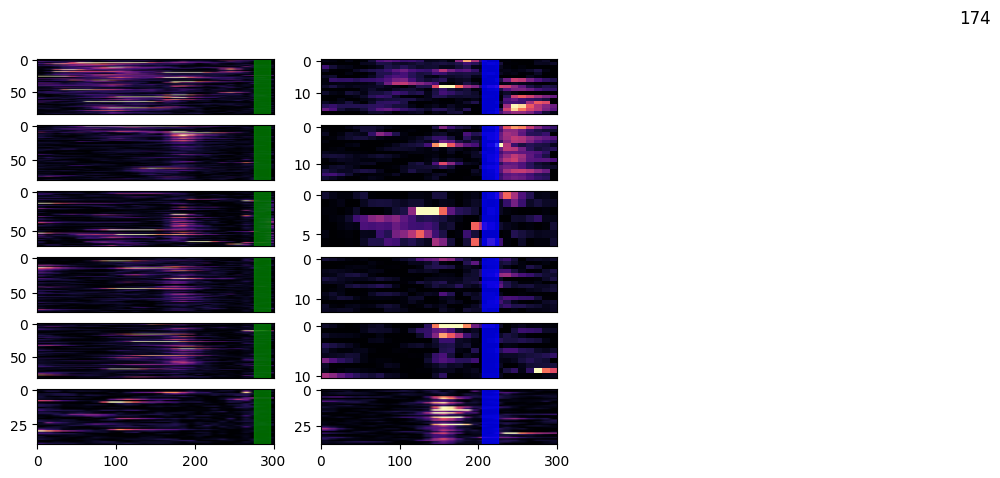

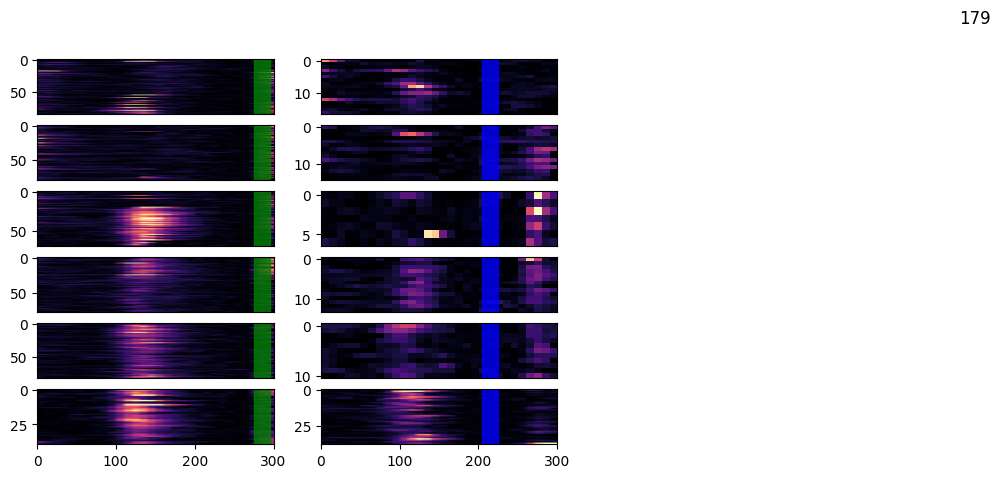

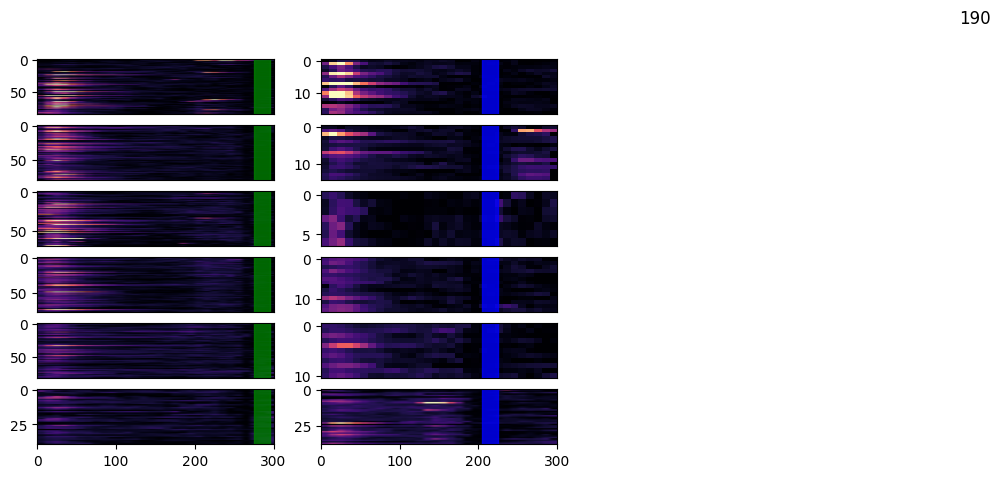

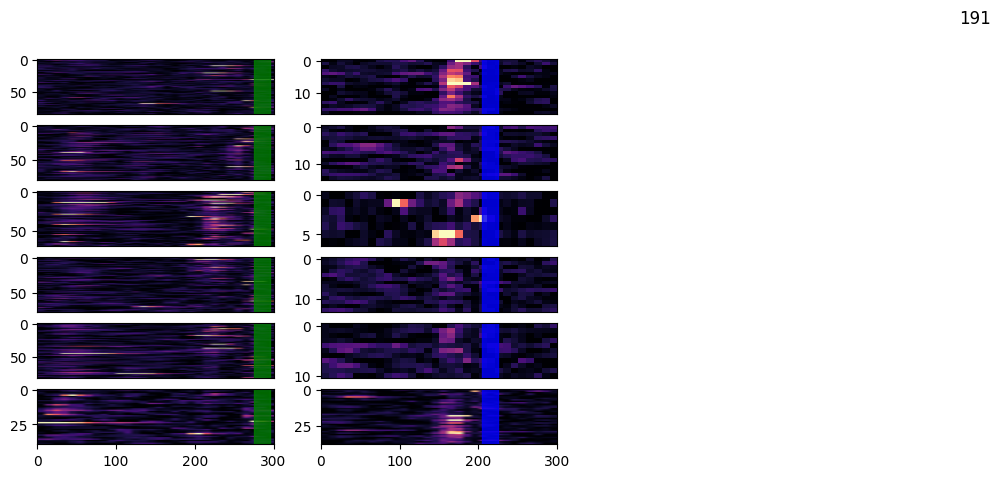

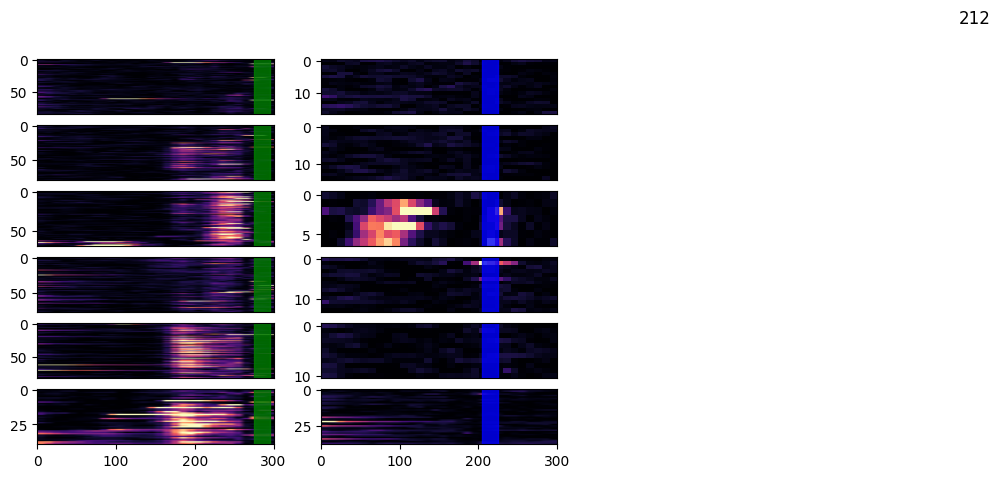

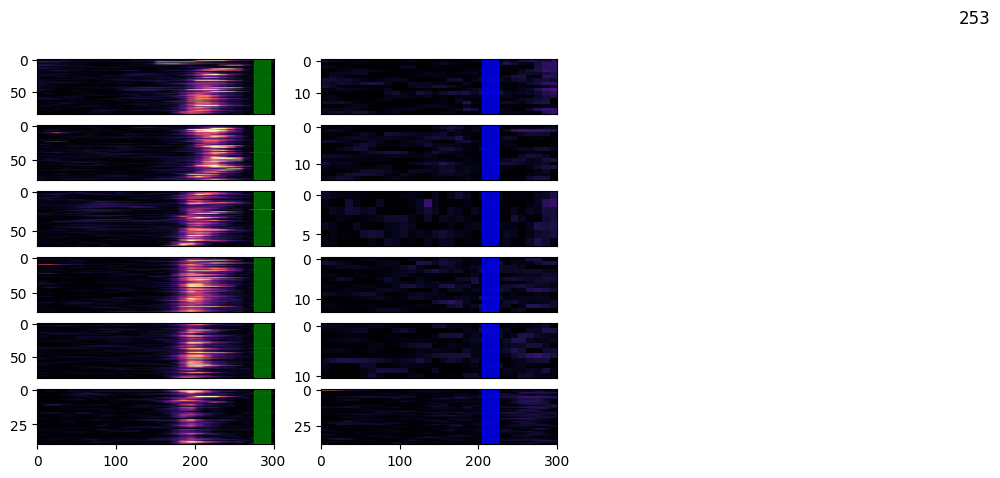

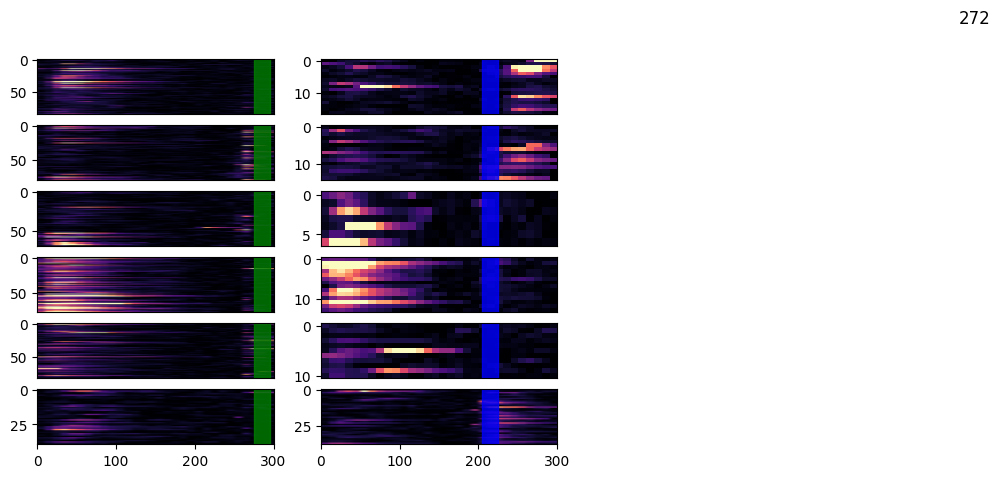

In [59]:
for cell in r_inds:
    _ = plot_cell_across_days(sess, cell)